### Importación de datos



In [37]:
import pandas as pd
import matplotlib.pyplot as plt


url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



##**Ingreso Total por cada tienda**


### Descripcion:
En este primer análisis, debes calcular el ingreso total de cada tienda. Sumando los valores de la columna Precio de cada conjunto de datos de la tienda para estimar los ingresos.

In [4]:
precioTotal1 = tienda['Precio'].sum()
precioTotal1

np.float64(1150880400.0)

In [5]:
precioTotal2 = tienda2['Precio'].sum()
precioTotal2

np.float64(1116343500.0)

In [6]:
precioTotal3 = tienda3['Precio'].sum()
precioTotal3

np.float64(1098019600.0)

In [7]:
precioTotal4 = tienda4['Precio'].sum()
precioTotal4

np.float64(1038375700.0)

#### La tienda con mayor ingresos fue la **Tienda 1**, con un ingreso de **$ 1.150.880.400**

#### **Visualizacion Grafica**


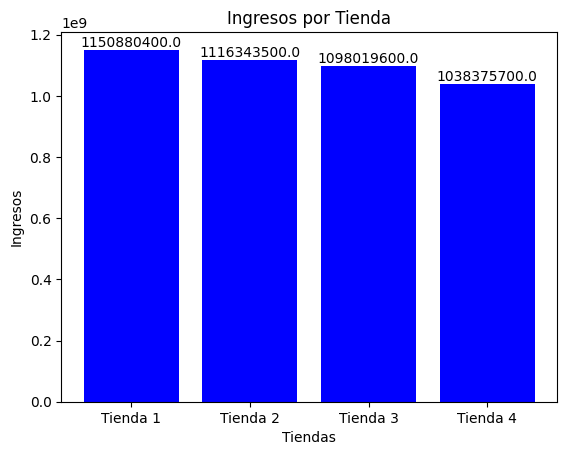

In [8]:
plt.bar(['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'], [precioTotal1, precioTotal2, precioTotal3, precioTotal4],color="blue")
for x, y in zip(['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'], [precioTotal1, precioTotal2, precioTotal3, precioTotal4]):
    plt.text(x, y, str(y), ha='center', va='bottom')

plt.xlabel('Tiendas')
plt.ylabel('Ingresos')
plt.title('Ingresos por Tienda')
plt.show()


# 2. Ventas por categoría

## Descripcion:
En este debes calcular la cantidad de productos vendidos por categoría en cada tienda. La idea es agrupar los datos por categoría y contar el número de ventas de cada tipo, mostrando las categorías más populares de cada tienda.


In [9]:
Venta_categoria1 = tienda.groupby('Categoría del Producto')['Producto'].count().reset_index(name="Ventas")
Venta_categoria1

,Categoría del Producto,Ventas
0,Artículos para el hogar,171
1,Deportes y diversión,284
2,Electrodomésticos,312
3,Electrónicos,448
4,Instrumentos musicales,182
5,Juguetes,324
6,Libros,173
7,Muebles,465


In [10]:
Venta_categoria2 = tienda2.groupby('Categoría del Producto')['Producto'].count().reset_index(name="Ventas")
Venta_categoria2

,Categoría del Producto,Ventas
0,Artículos para el hogar,181
1,Deportes y diversión,275
2,Electrodomésticos,305
3,Electrónicos,422
4,Instrumentos musicales,224
5,Juguetes,313
6,Libros,197
7,Muebles,442


In [11]:
Venta_categoria3 = tienda3.groupby('Categoría del Producto')['Producto'].count().reset_index(name="Ventas")
Venta_categoria3

,Categoría del Producto,Ventas
0,Artículos para el hogar,177
1,Deportes y diversión,277
2,Electrodomésticos,278
3,Electrónicos,451
4,Instrumentos musicales,177
5,Juguetes,315
6,Libros,185
7,Muebles,499


In [12]:
Venta_categoria4 = tienda4.groupby('Categoría del Producto')['Producto'].count().reset_index(name="Ventas")
Venta_categoria4

,Categoría del Producto,Ventas
0,Artículos para el hogar,201
1,Deportes y diversión,277
2,Electrodomésticos,254
3,Electrónicos,451
4,Instrumentos musicales,170
5,Juguetes,338
6,Libros,187
7,Muebles,480


#### Las categorias mas vendidas en todas las tiendas fueron **Muebles** y **Electronicos**.

#### **Visualizacion Grafica**

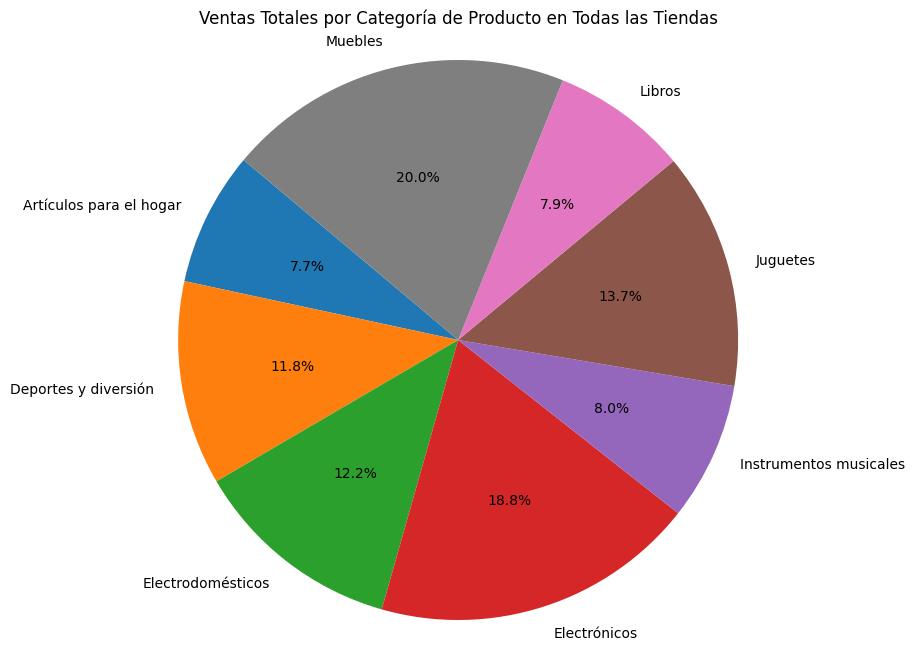

In [13]:
ventas_totales_categoria = pd.concat([
    Venta_categoria1,
    Venta_categoria2,
    Venta_categoria3,
    Venta_categoria4
]).groupby('Categoría del Producto')['Ventas'].sum().reset_index()

plt.figure(figsize=(10, 8))
plt.pie(ventas_totales_categoria['Ventas'], labels=ventas_totales_categoria['Categoría del Producto'], autopct='%1.1f%%', startangle=140)
plt.title('Ventas Totales por Categoría de Producto en Todas las Tiendas')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# 3. Calificación promedio de la tienda


## Descripcion:
En este paso, debes calcular las calificaciones promedio de los clientes para cada tienda. El objetivo es conocer la satisfacción del cliente con los productos vendidos.

In [14]:
promedio1 = tienda['Calificación'].mean()
print(f"Tienda 1: {promedio1:.2f}")


Tienda 1: 3.98


In [15]:
promedio2 = tienda2['Calificación'].mean()
print(f"Tienda 2: {promedio2:.2f}")

Tienda 2: 4.04


In [16]:
promedio3 = tienda3['Calificación'].mean()
print(f"Tienda 3: {promedio3:.2f}")

Tienda 3: 4.05


In [17]:
promedio4 = tienda4['Calificación'].mean()
print(f"Tienda 4: {promedio4:.2f}")

Tienda 4: 4.00


### La tienda con el mejor promedio de calificacion es, la **Tienda 3**, con un promedio de **4.05**

#### **Visualizacion Grafica**

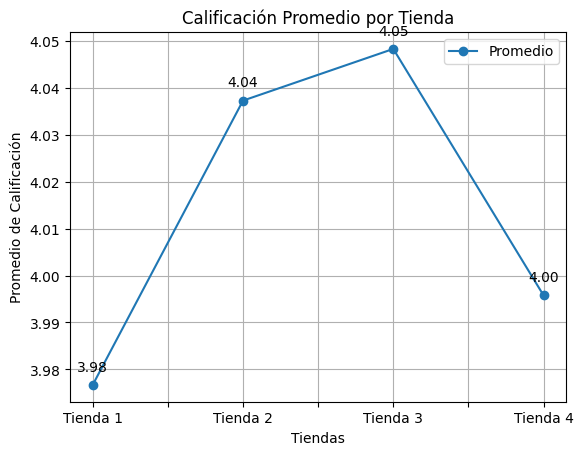

In [40]:
import matplotlib.pyplot as plt

promedio = [promedio1, promedio2, promedio3, promedio4]
tienda = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
data = {'Tienda': tienda, 'Promedio': promedio}
df = pd.DataFrame(data)

ax = df.plot(kind='line', x='Tienda', y='Promedio', marker='o')

# Add text labels for each point, using the numerical index 'i' for the x-coordinate
for i, txt in enumerate(df['Promedio']):
    ax.annotate(f'{txt:.2f}', (i, txt), textcoords="offset points", xytext=(0,10), ha='center')

plt.title('Calificación Promedio por Tienda')
plt.xlabel('Tiendas')
plt.ylabel('Promedio de Calificación')
plt.grid(True)
plt.show()

# 4. Productos más y menos vendidos

## Descripcion:
En este paso, debes identificar qué productos fueron los más vendidos y los menos vendidos en cada tienda. Visualiza los resultados para que quede claro qué productos destacaron en ventas en cada tienda.

In [26]:
#Primero cuento los productos por grupos
ventas = tienda.groupby('Producto')['Producto'].count().sort_values(ascending=False)

#luego calculo el maximo Producto mas vendido
mas_vendido = ventas.idxmax()
max_cant = ventas.max()

print(f"El producto mas vendido fue {mas_vendido} con {max_cant} ventas")

#luego calculo el minimo del Producto menos vendido
menos_vendido = ventas.idxmin()
min_cant = ventas.min()

print(f"El producto menos vendido fue {menos_vendido} con {min_cant} ventas")

El producto mas vendido fue Armario con 60 ventas
El producto menos vendido fue Celular ABXY con 33 ventas


In [27]:
#Primero cuento los productos por grupos
ventas = tienda2.groupby('Producto')['Producto'].count().sort_values(ascending=False)

#luego calculo el maximo Producto mas vendido
mas_vendido = ventas.idxmax()
max_cant = ventas.max()

print(f"El producto mas vendido fue {mas_vendido} con {max_cant} ventas")

#luego calculo el minimo del Producto menos vendido
menos_vendido = ventas.idxmin()
min_cant = ventas.min()

print(f"El producto menos vendido fue {menos_vendido} con {min_cant} ventas")

El producto mas vendido fue Iniciando en programación con 65 ventas
El producto menos vendido fue Juego de mesa con 32 ventas


In [28]:
#Primero cuento los productos por grupos
ventas = tienda3.groupby('Producto')['Producto'].count().sort_values(ascending=False)

#luego calculo el maximo Producto mas vendido
mas_vendido = ventas.idxmax()
max_cant = ventas.max()

print(f"El producto mas vendido fue {mas_vendido} con {max_cant} ventas")

#luego calculo el minimo del Producto menos vendido
menos_vendido = ventas.idxmin()
min_cant = ventas.min()

print(f"El producto menos vendido fue {menos_vendido} con {min_cant} ventas")

El producto mas vendido fue Kit de bancas con 57 ventas
El producto menos vendido fue Bloques de construcción con 35 ventas


In [29]:
#Primero cuento los productos por grupos
ventas = tienda4.groupby('Producto')['Producto'].count().sort_values(ascending=False)

#luego calculo el maximo Producto mas vendido
mas_vendido = ventas.idxmax()
max_cant = ventas.max()

print(f"El producto mas vendido fue {mas_vendido} con {max_cant} ventas")

#luego calculo el minimo del Producto menos vendido
menos_vendido = ventas.idxmin()
min_cant = ventas.min()

print(f"El producto menos vendido fue {menos_vendido} con {min_cant} ventas")

El producto mas vendido fue Cama box con 62 ventas
El producto menos vendido fue Guitarra eléctrica con 33 ventas


#### **Visualizacion Grafica**

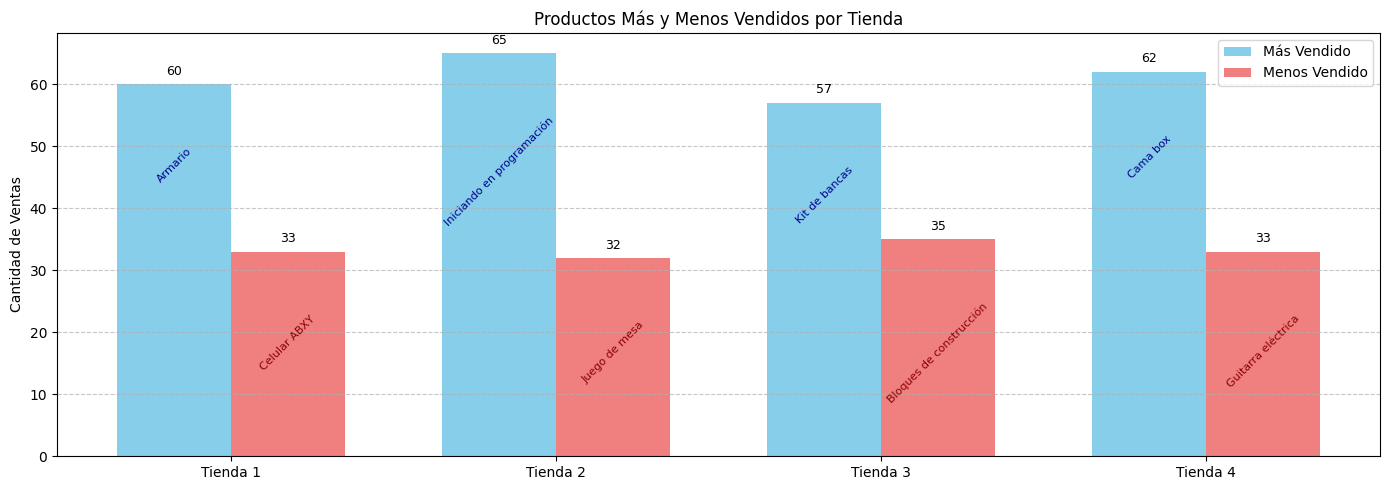

In [48]:

import numpy as np

def get_product_sales_data(df, store_name):
    ventas = df.groupby('Producto')['Producto'].count().sort_values(ascending=False)
    mas_vendido_name = ventas.idxmax()
    mas_vendido_count = ventas.max()
    menos_vendido_name = ventas.idxmin()
    menos_vendido_count = ventas.min()
    return {
        'Store': store_name,
        'Producto': [mas_vendido_name, menos_vendido_name],
        'Cantidad': [mas_vendido_count, menos_vendido_count],
        'Tipo': ['Más Vendido', 'Menos Vendido']
    }

tienda1_df = pd.read_csv(url)

data_tienda1 = get_product_sales_data(tienda1_df, 'Tienda 1')
data_tienda2 = get_product_sales_data(tienda2, 'Tienda 2')
data_tienda3 = get_product_sales_data(tienda3, 'Tienda 3')
data_tienda4 = get_product_sales_data(tienda4, 'Tienda 4')


combined_data = pd.concat([
    pd.DataFrame(data_tienda1),
    pd.DataFrame(data_tienda2),
    pd.DataFrame(data_tienda3),
    pd.DataFrame(data_tienda4)
]).reset_index(drop=True)


fig, ax = plt.subplots(figsize=(14, 5))

stores = combined_data['Store'].unique()
product_types = combined_data['Tipo'].unique()

width = 0.35
ind = np.arange(len(stores))


mas_vendido_counts = [combined_data[(combined_data['Store'] == s) & (combined_data['Tipo'] == 'Más Vendido')]['Cantidad'].iloc[0] for s in stores]
rects1 = ax.bar(ind - width/2, mas_vendido_counts, width, label='Más Vendido', color='skyblue')

menos_vendido_counts = [combined_data[(combined_data['Store'] == s) & (combined_data['Tipo'] == 'Menos Vendido')]['Cantidad'].iloc[0] for s in stores]
rects2 = ax.bar(ind + width/2, menos_vendido_counts, width, label='Menos Vendido', color='lightcoral')


for i, store in enumerate(stores):
    mas_vendido_product = combined_data[(combined_data['Store'] == store) & (combined_data['Tipo'] == 'Más Vendido')]['Producto'].iloc[0]
    menos_vendido_product = combined_data[(combined_data['Store'] == store) & (combined_data['Tipo'] == 'Menos Vendido')]['Producto'].iloc[0]

    ax.text(ind[i] - width/2, mas_vendido_counts[i] + 1, f'{mas_vendido_counts[i]}', ha='center', va='bottom', fontsize=9, color='black')
    ax.text(ind[i] + width/2, menos_vendido_counts[i] + 1, f'{menos_vendido_counts[i]}', ha='center', va='bottom', fontsize=9, color='black')


    ax.text(ind[i] - width/2, mas_vendido_counts[i] - 10, f'{mas_vendido_product}', ha='center', va='top', fontsize=8, color='darkblue', rotation=45)
    ax.text(ind[i] + width/2, menos_vendido_counts[i] - 10, f'{menos_vendido_product}', ha='center', va='top', fontsize=8, color='darkred', rotation=45)


ax.set_ylabel('Cantidad de Ventas')
ax.set_title('Productos Más y Menos Vendidos por Tienda')
ax.set_xticks(ind)
ax.set_xticklabels(stores)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 5. Envío promedio por tienda

### Descrpcion:
En este paso, debes calcular el costo de envío promedio para cada tienda. El objetivo es comprender cuánto se gasta, en promedio, en el envío de cada tienda.  Sabiendo que el cliente paga el envío.

In [22]:
costo_envio1 = tienda['Costo de envío'].mean()
print(f"la Tienda 1, tiene un costo de envio de: {costo_envio1:.2f}")

la Tienda 1, tiene un costo de envio de: 26018.61


In [23]:
costo_envio2 = tienda2['Costo de envío'].mean()
print(f"la Tienda 2, tiene un costo de envio de: {costo_envio2:.2f}")


la Tienda 2, tiene un costo de envio de: 25216.24


In [24]:
costo_envio3 = tienda3['Costo de envío'].mean()
print(f"la Tienda 3, tiene un costo de envio de: {costo_envio3:.2f}")


la Tienda 3, tiene un costo de envio de: 24805.68


In [25]:
costo_envio4 = tienda4['Costo de envío'].mean()
print(f"la Tienda 4, tiene un costo de envio de: {costo_envio4:.2f}")

la Tienda 4, tiene un costo de envio de: 23459.46


#### **Visualizacion Grafica**

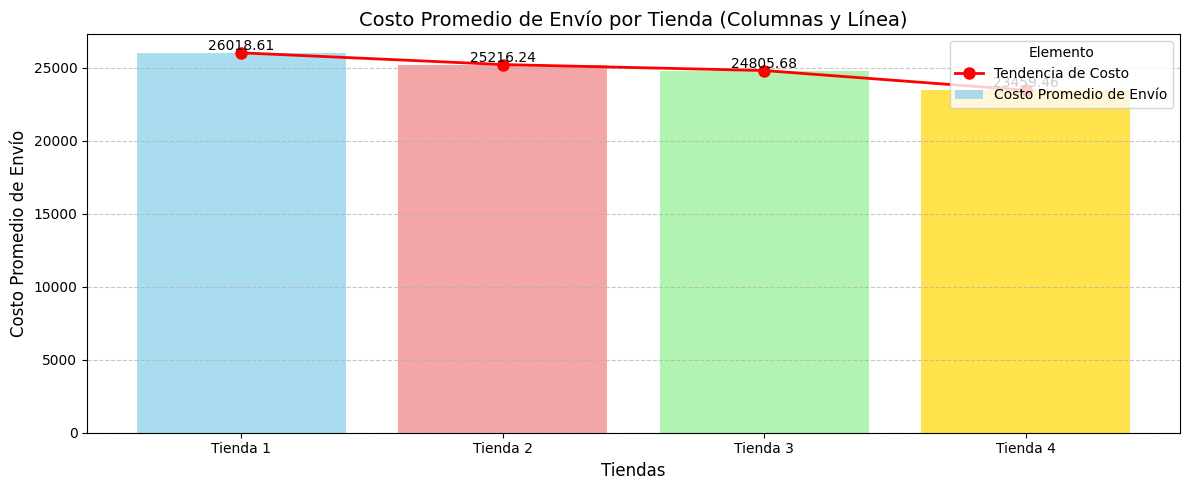

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create a DataFrame for easier plotting
df_costos = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Costo Promedio de Envío': [costo_envio1, costo_envio2, costo_envio3, costo_envio4]
})

plt.figure(figsize=(12, 5))

stores = df_costos['Tienda']
costs = df_costos['Costo Promedio de Envío']
x_positions = np.arange(len(stores)) # Numerical positions for x-axis
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold']

# Create the bar chart (columns)
plt.bar(x_positions, costs, color=colors, alpha=0.7, label='Costo Promedio de Envío')

# Add a line connecting the top of the bars
plt.plot(x_positions, costs, color='red', linestyle='-', marker='o', markersize=8, linewidth=2, label='Tendencia de Costo')

# Add text labels for the values on top of the bars
for i, cost in enumerate(costs):
    plt.text(x_positions[i], cost, f'{cost:.2f}', ha='center', va='bottom', fontsize=10, color='black')

plt.xticks(x_positions, stores) # Set categorical labels for x-axis
plt.xlabel('Tiendas', fontsize=12)
plt.ylabel('Costo Promedio de Envío', fontsize=12)
plt.title('Costo Promedio de Envío por Tienda (Columnas y Línea)', fontsize=14)
plt.legend(title='Elemento', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(bottom=0) # Ensure y-axis starts from 0
plt.tight_layout()
plt.show()